<a href="https://colab.research.google.com/github/vineetsalar88/ResearchPaper2/blob/master/April2026/2aprilConvNeXt_tiny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

train_dir = "/content/drive/MyDrive/ResearchData/April26/TrainvsTestDataset1108images/train"
val_dir =   "/content/drive/MyDrive/ResearchData/April26/TrainvsTestDataset1108images/val"
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = len(os.listdir(train_dir))

In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [4]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.convnext_tiny(pretrained=True)

# Replace classifier
model.classifier[2] = nn.Linear(model.classifier[2].in_features, NUM_CLASSES)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:01<00:00, 113MB/s]


In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=3e-4)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [7]:
EPOCHS = 20

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    # -------- TRAIN --------
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # -------- VALIDATION --------
    model.eval()
    running_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(val_loader)
    val_losses.append(val_loss)

    acc = accuracy_score(all_labels, all_preds)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {acc:.4f}")

    scheduler.step()



Epoch 1/20
Train Loss: 1.0197 | Val Loss: 0.9127 | Acc: 0.6071
Epoch 2/20
Train Loss: 0.7325 | Val Loss: 0.6520 | Acc: 0.7589
Epoch 3/20
Train Loss: 0.4556 | Val Loss: 0.6697 | Acc: 0.7143
Epoch 4/20
Train Loss: 0.3955 | Val Loss: 0.7141 | Acc: 0.7277
Epoch 5/20
Train Loss: 0.3165 | Val Loss: 0.7110 | Acc: 0.7679
Epoch 6/20
Train Loss: 0.1321 | Val Loss: 0.5878 | Acc: 0.8036
Epoch 7/20
Train Loss: 0.0556 | Val Loss: 0.6133 | Acc: 0.7991
Epoch 8/20
Train Loss: 0.0382 | Val Loss: 0.6389 | Acc: 0.7991
Epoch 9/20
Train Loss: 0.0347 | Val Loss: 0.6137 | Acc: 0.8304
Epoch 10/20
Train Loss: 0.0176 | Val Loss: 0.6298 | Acc: 0.8125
Epoch 11/20
Train Loss: 0.0152 | Val Loss: 0.6420 | Acc: 0.8036
Epoch 12/20
Train Loss: 0.0233 | Val Loss: 0.7300 | Acc: 0.8125
Epoch 13/20
Train Loss: 0.0124 | Val Loss: 0.6948 | Acc: 0.8036
Epoch 14/20
Train Loss: 0.0102 | Val Loss: 0.6786 | Acc: 0.8036
Epoch 15/20
Train Loss: 0.0059 | Val Loss: 0.6782 | Acc: 0.7946
Epoch 16/20
Train Loss: 0.0096 | Val Loss: 0.7034

KeyboardInterrupt: 

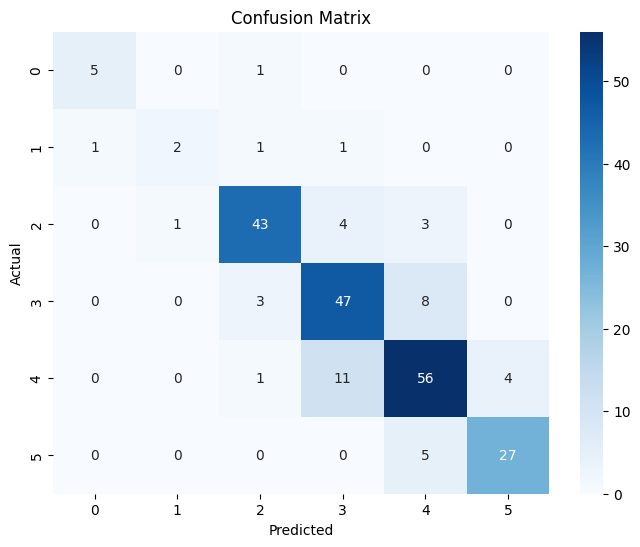

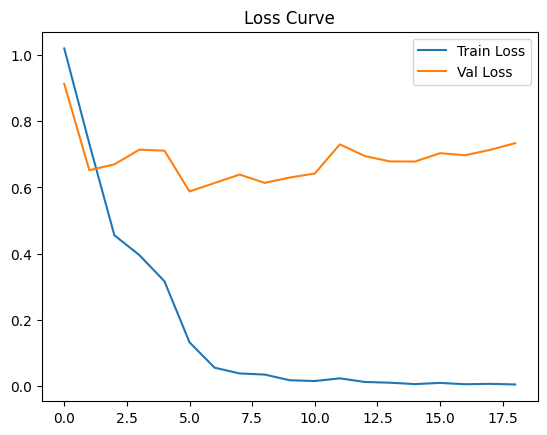

In [8]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
torch.save(model.state_dict(), "convnext_model.pth")
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()